In [45]:
import rasterio
import geopandas as gpd
import numpy as np
from rasterio.mask import mask
from shapely.geometry import box
import matplotlib.pyplot as plt
from rasterio.plot import show
import pandas as pd
from shapely import wkt
import json
def geo_to_pixel(geo_x, geo_y, transform):
    """Convert geographic coordinates to pixel coordinates."""
    col = int((geo_x - transform.c) / transform.a)
    row = int((geo_y - transform.f) / transform.e)
    return row, col

def pixel_to_geo(row, col, transform):
    """Convert pixel coordinates to geographic coordinates."""
    geo_x = transform.c + col * transform.a
    geo_y = transform.f + row * transform.e
    return geo_x, geo_y

def plot_gdf_bbox_on_raster(tif_path, gdf_patches, zoom_to_gdf=False):
    """
    Plot GDF bounding box on top of the raster using the raster's transform.
    
    Args:
        tif_path (str): Path to the GeoTIFF file
        gdf_patches (gpd.GeoDataFrame): GeoDataFrame with patch geometries
        zoom_to_gdf (bool): If True, zoom the view to the GDF extent
    """
    with rasterio.open(tif_path) as src:
        # Reproject patches if needed
        if gdf_patches.crs != src.crs:
            gdf_patches = gdf_patches.to_crs(src.crs)
        
        # Get the bounding box of the entire GDF
        gdf_bounds = gdf_patches.total_bounds  # (minx, miny, maxx, maxy)
        
        # Convert bounding box corners to pixel coordinates
        row_min, col_min = geo_to_pixel(gdf_bounds[0], gdf_bounds[3], src.transform)
        row_max, col_max = geo_to_pixel(gdf_bounds[2], gdf_bounds[1], src.transform)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 10))
        
        # Show raster
        show(src, ax=ax, cmap='terrain')
        
        # Create rectangle for bounding box in geographic coordinates
        from matplotlib.patches import Rectangle
        bbox_width = gdf_bounds[2] - gdf_bounds[0]
        bbox_height = gdf_bounds[3] - gdf_bounds[1]
        
        rect = Rectangle(
            (gdf_bounds[0], gdf_bounds[1]),  # Lower left corner
            bbox_width, 
            bbox_height,
            linewidth=3,
            edgecolor='blue',
            facecolor='none',
            label='GDF Bounding Box',
            zorder=10
        )
        ax.add_patch(rect)
        
        # Overlay all patch boundaries
        gdf_patches.boundary.plot(ax=ax, color='red', linewidth=2, alpha=0.9, label='Patches', zorder=11)
        
        # Zoom to GDF extent if requested
        if zoom_to_gdf:
            # Add some padding (10% of the width/height)
            pad_x = bbox_width * 0.1
            pad_y = bbox_height * 0.1
            ax.set_xlim(gdf_bounds[0] - pad_x, gdf_bounds[2] + pad_x)
            ax.set_ylim(gdf_bounds[1] - pad_y, gdf_bounds[3] + pad_y)
        
        # Add legend
        ax.legend(loc='upper right')
        
        # Print info
        print(f"GDF Bounding Box (geographic): {gdf_bounds}")
        print(f"GDF Bounding Box (pixels): row [{row_min}, {row_max}], col [{col_min}, {col_max}]")
        print(f"Raster Bounds: {src.bounds}")
        
        plt.title('GDF Bounding Box and Patches on GeoTIFF')
        plt.tight_layout()
        plt.show()


def visualize_patch_overlay(tif_path, gdf_patches, num_samples=5):
    """Visualize a few patches overlaid on the raster."""
    with rasterio.open(tif_path) as src:
        # Reproject patches if needed
        if gdf_patches.crs != src.crs:
            gdf_patches = gdf_patches.to_crs(src.crs)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 10))
        
        # Show raster
        show(src, ax=ax, cmap='terrain')
        
        # Overlay sample patches
        sample_patches = gdf_patches.sample(min(num_samples, len(gdf_patches)))
        sample_patches.boundary.plot(ax=ax, color='red', linewidth=2)
        
        plt.title('Patches Overlaid on GeoTIFF')
        plt.tight_layout()
        plt.show()

def plot_gdf_on_tiff(tif_path, gdf_patches):
    """Plot GDF patch boundaries on top of the GeoTIFF."""
    with rasterio.open(tif_path) as src:
        # Reproject patches if needed
        if gdf_patches.crs != src.crs:
            gdf_patches = gdf_patches.to_crs(src.crs)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(15, 10))
        
        # Show raster
        show(src, ax=ax, cmap='terrain')
        
        # Overlay all patch boundaries
        gdf_patches.boundary.plot(ax=ax, color='red', linewidth=1)
        
        plt.title('GDF Patches on GeoTIFF')
        plt.tight_layout()
        plt.show()

In [46]:
gdf = gpd.read_file("metadata_saved_as_fallback.geojson")
expected = gpd.read_file("gpkgs/hedgementation_dataset_1.2.gpkg")

In [47]:
gdf["hedgerows"].iloc[0]

'{ "coordinates": [ [ -3.5648460000000002, 48.731026 ], [ -3.5648279999999999, 48.730907000000002 ], [ -3.5646939999999998, 48.730800000000002 ], [ -3.564635, 48.730682999999999 ], [ -3.5645720000000001, 48.730623000000001 ], [ -3.5645389999999999, 48.730555000000003 ], [ -3.5644740000000001, 48.730519000000001 ], [ -3.5643590000000001, 48.730491000000001 ] ], "type": "LineString" }'

In [48]:
expected["dates-s2"] = gdf["dates-s2"]

In [49]:
expected.to_file("metadata_with_dates_s2.geojson")

In [50]:
gdf["dates-s2"]

0       2021-09-21,2021-09-23,2021-10-08,2021-10-11,20...
1       2021-10-08,2021-10-11,2021-10-13,2021-10-31,20...
2       2021-10-08,2021-10-11,2021-10-13,2021-10-31,20...
3       2021-10-08,2021-10-11,2021-10-13,2021-10-31,20...
4       2021-10-08,2021-10-11,2021-10-13,2021-10-31,20...
                              ...                        
2990    2021-09-21,2021-09-24,2021-10-01,2021-10-09,20...
2991    2021-09-18,2021-09-18,2021-09-18,2021-09-18,20...
2992    2021-09-18,2021-09-23,2021-09-28,2021-09-30,20...
2993    2021-09-18,2021-09-20,2021-09-23,2021-09-28,20...
2994    2021-09-18,2021-09-18,2021-09-20,2021-09-23,20...
Name: dates-s2, Length: 2995, dtype: object

In [51]:
len(gdf)

2995

In [52]:
gdf = gdf.drop(columns=[c for c in gdf.columns if not (c in list(expected.columns))])
gdf = gdf.drop(columns=["geometry", "hedgerows"])
expected = expected.drop(columns=["geometry", "hedgerows"])

In [53]:
pd.testing.assert_frame_equal(
    gdf.reindex(sorted(gdf.columns), axis=1),
    expected.reindex(sorted(expected.columns), axis=1),
    check_dtype=False
)

In [54]:
import os
import numpy as np
import rasterio
from rasterio.features import geometry_mask

gdf = gpd.read_file("gpkgs/haie_2024_france_patches_2024_merged.gpkg")

def count_zeroes(tif_path,gdf):
    with rasterio.open(tif_path) as src:
        if gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)
        
        gdf_bounds = gdf.total_bounds 
        
        window = rasterio.windows.from_bounds(*gdf_bounds, transform=src.transform)
        arr = src.read(1, window=window)  
                
        zeropct = np.sum((arr == 0)) / np.sum(np.ones(arr.shape))
    return zeropct

def find_min_zeros(gdf,dir):
    files = os.listdir(dir)

    min_zeropct = float("inf")
    min_zero_file = ""
    for f in files:
        if f[:3] != "aez" or not f.endswith(".tif"):
            continue
        zero_pct = count_zeroes(os.path.join(dir, f), gdf)
        
        if min_zeropct > zero_pct:
            min_zeropct = zero_pct
            min_zero_file = f
            print(f"New min zero pct found:{zero_pct}")
    return min_zeropct,min_zero_file

mzc,mzf=find_min_zeros(gdf, "LR/aez")
    

New min zero pct found:0.2819381993735172
New min zero pct found:0.26004114420062696


In [55]:
mzf

'aez_v9v2red_5m_ENSEMBLE_rcp8p5_2020s.tif'

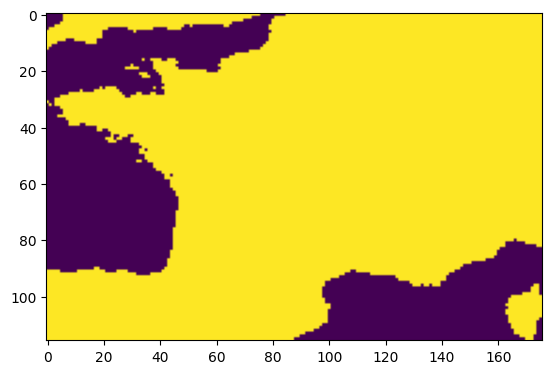

In [56]:
with rasterio.open(f"LR/aez/{mzf}") as src:
        if gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)
        
        gdf_bounds = gdf.total_bounds 
        
        window = rasterio.windows.from_bounds(*gdf_bounds, transform=src.transform)
        arr = src.read(1, window=window)  
        nonzeros = arr != 0
        plt.imshow(arr)
        plt.imshow(nonzeros)

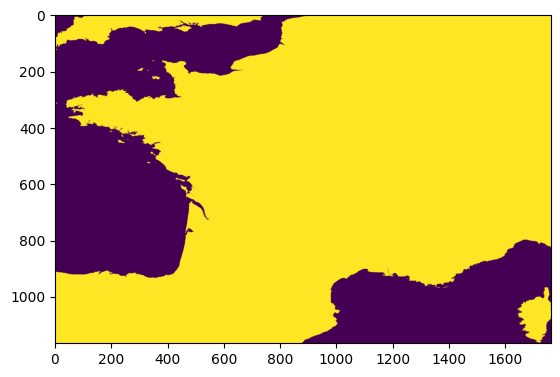

In [57]:
with rasterio.open(f"LR/aez/aez_v9v2_CRUTS32_Hist_8110_100_avg.tif") as src:
        if gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)
        
        gdf_bounds = gdf.total_bounds 
        
        window = rasterio.windows.from_bounds(*gdf_bounds, transform=src.transform)
        arr = src.read(1, window=window)  
        nonzeros = arr != 0
        plt.imshow(arr)
        plt.imshow(nonzeros)

In [58]:
np.unique(arr,return_counts=True)

(array([ 0, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 33, 34, 35, 36,
        39, 40, 41, 42, 47, 48, 49, 50, 51, 52, 55, 56, 57], dtype=uint8),
 array([578743,    381,   2862,  10124,  18883,  17204,  30042,   4789,
         18559,  23730,  71841,  38582,  46260,   1628,   5001,   2021,
           910, 158469, 148766, 229927, 271990,     37,   1840,  99573,
        112257, 105372,  17670,   2555,  27676,   5038]))

In [59]:
np.sum((arr == 0))

np.int64(578743)